In [5]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Settings
plt.style.use('dark_background')
COLORS = ['#00d4ff', '#ff007f', '#39ff14', '#ffd700']
METRICS_FILE = "../evaluation/reports/rl_metrics.json"

## 1. RL Performance Summary

In [6]:
with open(METRICS_FILE, 'r') as f:
    all_metrics = json.load(f)

df_dqn = pd.Series([m for m in all_metrics if m['agent'] == 'DQN'][0])
print("DQN Evaluation Scorecard")
print("="*30)
print(df_dqn[["success_rate", "sla_breach_rate", "avg_reward", "avg_steps"]])

DQN Evaluation Scorecard
success_rate           0.825
sla_breach_rate        0.065
avg_reward         25.003447
avg_steps              1.765
dtype: object


## 2. Interaction Efficiency

C:\Users\Samridhaa\AppData\Local\Temp\ipykernel_20548\3279178281.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Avg Steps", "Max Steps"], y=[df_dqn["avg_steps"], 6.0], palette=COLORS)
C:\Users\Samridhaa\AppData\Local\Temp\ipykernel_20548\3279178281.py:2: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.barplot(x=["Avg Steps", "Max Steps"], y=[df_dqn["avg_steps"], 6.0], palette=COLORS)


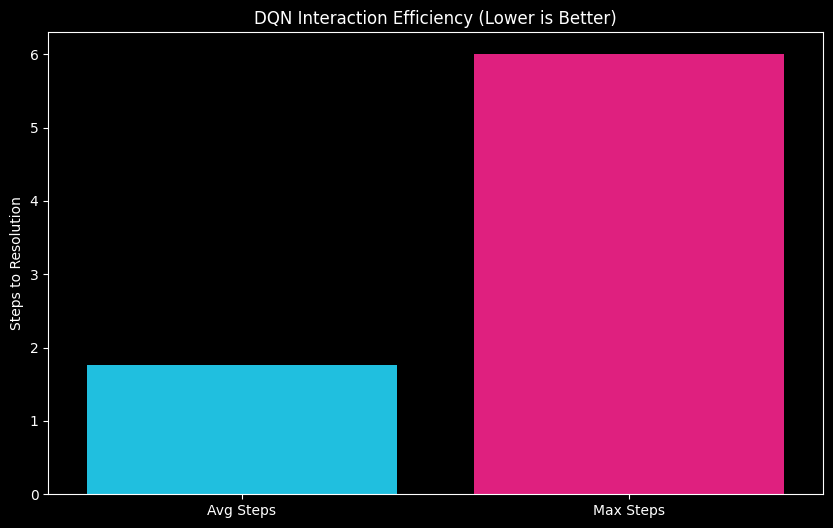

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(x=["Avg Steps", "Max Steps"], y=[df_dqn["avg_steps"], 6.0], palette=COLORS)
plt.title("DQN Interaction Efficiency (Lower is Better)")
plt.ylabel("Steps to Resolution")
plt.show()

## 3. RL Confidence & Strategy Confidence

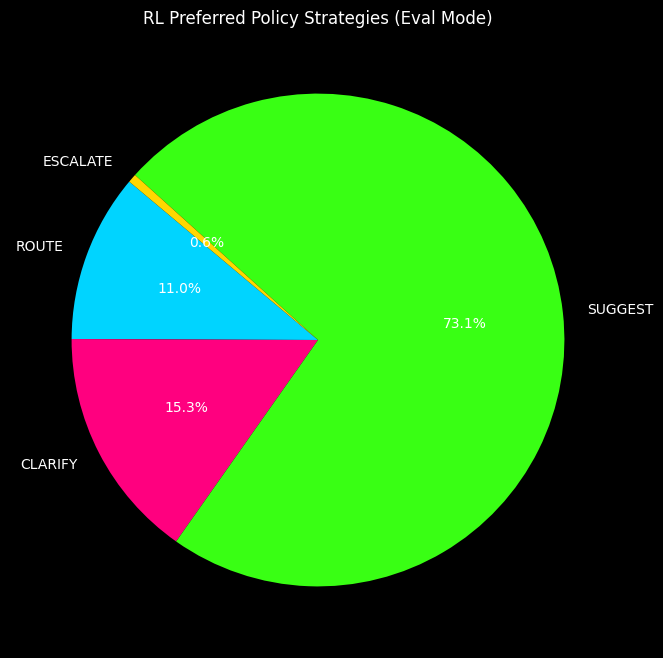

In [8]:
strats = df_dqn['strategy_distribution']
plt.figure(figsize=(8, 8))
plt.pie(strats.values(), labels=strats.keys(), autopct='%1.1f%%', colors=COLORS, startangle=140)
plt.title("RL Preferred Policy Strategies (Eval Mode)")
plt.show()